# Factor in Practice Part 2
### How Can We Predict Stock Prices from Historical Data?

##### Note: this notebook is intended for students who already have some machine learning background. In the age of AI and the internet, acquiring knowledge is easy. Applying knowledge is still difficult, because application requires a large amount of practice. This notebook walks through the process of building a factor step by step from scratch. The goal is that you learn something useful by following the full workflow.

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime,timedelta
import os
import re
from sklearn.model_selection import train_test_split 
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_log_error

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import learning_curve
from sklearn.model_selection import validation_curve
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import LeavePOut
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import PredefinedSplit
from sklearn.model_selection import ParameterGrid
from sklearn.model_selection import ParameterSampler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import learning_curve
from sklearn.model_selection import validation_curve
from sklearn.model_selection import cross_val_score

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

from sklearn.datasets import load_iris
from sklearn.datasets import load_digits
from sklearn.datasets import make_classification
from sklearn.datasets import make_blobs
from sklearn.datasets import make_gaussian_quantiles
from sklearn.datasets import make_hastie_10_2

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.feature_selection import f_regression
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectFromModel

from sklearn.decomposition import PCA
from sklearn.decomposition import FactorAnalysis
from sklearn.decomposition import FastICA

from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans
from sklearn.cluster import DBSCAN

from sklearn.manifold import TSNE
from sklearn.manifold import Isomap
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.manifold import MDS

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.svm import SVR
from sklearn.svm import LinearSVR

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.linear_model import SGDClassifier

from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_graphviz

from warnings import filterwarnings
filterwarnings('ignore')

import matplotlib.pyplot as plt

## Load US market data via yfinance

Reason: macro market data matters for stocks, so we need to read it in. In the US market, macro factors play an important role alongside firm-specific factors, because institutional behavior and market-wide sentiment can drive individual stock prices. Macro factors and individual stock factors influence each other in a two-way relationship. This interaction is important enough to repeat more than once.


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

tickers = ['AAPL', 'MSFT']
start = '2016-01-01'
end = '2022-12-31'

all_data = []
for ticker in tickers:
    stock = yf.Ticker(ticker)
    hist = stock.history(start=start, end=end)
    hist = hist.reset_index()
    hist['Symbol'] = ticker
    info = stock.info
    hist['ShortName'] = info.get('shortName', ticker)
    hist['TradingDate'] = hist['Date'].dt.strftime('%Y-%m-%d')
    hist['Ret'] = hist['Close']
    hist['ChangeRatio'] = hist['Close'].pct_change()
    hist['Amount'] = hist['Volume'] * hist['Close']
    hist['MarketCap'] = hist['Close'] * info.get('sharesOutstanding', 1e9)
    hist['ILLIQ'] = hist['ChangeRatio'].abs() / (hist['Amount'] + 1e-10)
    hist['PE'] = info.get('trailingPE', np.nan)
    hist['PB'] = info.get('priceToBook', np.nan)
    hist['PS'] = info.get('priceToSalesTrailing12Months', np.nan)
    hist['Turnover'] = hist['Volume'] / info.get('sharesOutstanding', 1e9)
    all_data.append(hist)

factor = pd.concat(all_data, axis=0)
factor = factor.sort_values(by=['Symbol', 'TradingDate']).reset_index(drop=True)
factor = factor[['Symbol', 'ShortName', 'TradingDate', 'Ret', 'PE', 'PB', 'PS', 'Turnover', 'MarketCap', 'ChangeRatio', 'Amount', 'ILLIQ']]

# Build X (features) and y (daily returns)
X_base = factor[['ILLIQ', 'PE', 'PB', 'PS', 'MarketCap', 'ChangeRatio', 'Turnover']].rename(
    columns={'MarketCap': 'CirculatedMarketValue', 'Turnover': 'Liquidility'}
)
y_base = factor['ChangeRatio'].rename('Dretwd')

factor

YFRateLimitError: Too Many Requests. Rate limited. Try after a while.

In [ ]:
df_new_data

In [ ]:
df_x = X_base.copy()
df_x

In [ ]:
df_y = y_base.to_frame()
df_y

## After adding macro factors

### // Steps:
#### // 1. Read the macro market data
#### // 2. Merge it into the factor dataset by date
#### // (Try this as an exercise after class. The real challenge here is careful merging. In practice, time-series data often need to be loaded multiple times, aligned carefully, and checked with patience.)
#### Hint

```python 
df_merge = pd.merge(df, df_new_data, on='Trddt', how='left')
```


In [ ]:
## After adding macro factors

### // Steps:
#### // 1. Use US market index data (e.g., SPY) as the macro factor
#### // 2. Merge it into the factor dataset by date
#### // (Try this as an exercise after class. The real challenge here is careful merging. In practice, time-series data often need to be loaded multiple times, aligned carefully, and checked with patience.)
#### Hint

```python 
spy = yf.Ticker('SPY').history(start='2016-01-01', end='2022-12-31')
spy['market_return'] = spy['Close'].pct_change()
df_merge = pd.merge(df, spy[['market_return']], left_on='Trddt', right_index=True, how='left')
```


In [ ]:
# Load SPY as a macro market factor and merge with our factor data
spy = yf.Ticker('SPY')
spy_hist = spy.history(start='2016-01-01', end='2022-12-31').reset_index()
spy_hist['TradingDate'] = spy_hist['Date'].dt.strftime('%Y-%m-%d')
spy_hist['spy_return'] = spy_hist['Close'].pct_change()
spy_hist['spy_volume'] = spy_hist['Volume']

df_merged = pd.merge(
    factor[['Symbol', 'TradingDate', 'ILLIQ', 'PE', 'PB', 'PS', 'MarketCap', 'ChangeRatio', 'Turnover']],
    spy_hist[['TradingDate', 'spy_return', 'spy_volume']],
    on='TradingDate',
    how='left'
).rename(columns={'MarketCap': 'CirculatedMarketValue', 'Turnover': 'Liquidility'})

df = df_merged
df

In [ ]:
X = df[['ILLIQ', 'PE', 'PB', 'PS', 'CirculatedMarketValue', 'ChangeRatio', 'Liquidility', 'spy_return', 'spy_volume']]


In [ ]:
y = df['ChangeRatio'].rename('Dretwd')

In [ ]:
y_shift_one.fillna(method='ffill', inplace=True)

## Take another look at the factor data


In [ ]:
X

In [ ]:
y_shift_one

# Time-series models:

- ARIMA (Autoregressive Integrated Moving Average)
- GARCH (Generalized Autoregressive Conditional Heteroskedasticity)
- LSTM (Long Short-Term Memory) networks

# Machine learning models:

- Linear regression
- Random forest
- Support vector machine (SVM)
- Gradient-boosted tree models such as XGBoost or LightGBM

# Deep learning models:

- Convolutional neural networks (CNNs) for chart-like inputs
- Recurrent neural networks (RNNs) or LSTMs for sequence forecasting
- Attention mechanisms for sequence modeling


In [ ]:
! pip3.9 install xgboost

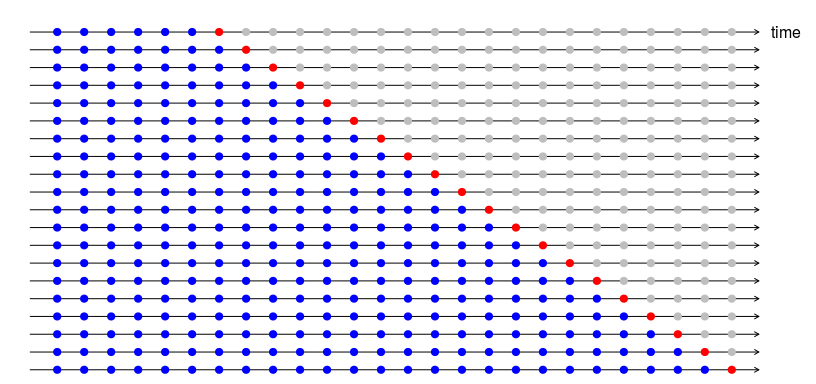


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.decomposition import TruncatedSVD
import xgboost as xgb
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings


### Some thoughts on handling time-series data


In [ ]:
# No one can predict the future (no look-ahead bias)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # shuffle=True would leak future data

X_train, X_test, y_train, y_test = train_test_split(X, y_shift_one, test_size=0.2, shuffle=False)

# Advanced approach: Time Series Cross Validation:
# tscv = TimeSeriesSplit(n_splits=5)
# for train_index, test_index in tscv.split(y):
    # y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # arima_model = ARIMA(y_train, order=(5,1,0))
    # arima_model_fit = arima_model.fit()
    # y_pred_arima = arima_model_fit.forecast(steps=len(y_test))
    # rmse_arima = np.sqrt(mean_squared_error(y_test, y_pred_arima))
    # rmse_arima_scores.append(rmse_arima)
    # average_rmse_arima = np.mean(rmse_arima_scores)


### Linear regression model


In [ ]:
# Linear Regression Model
# Train and evaluate a simple linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
win_ratio_lr = np.mean(np.sign(y_pred_lr) == np.sign(y_test.values))

print('Linear Regression RMSE: ', rmse_lr)
print('Linear Regression Win Ratio: ', win_ratio_lr)

In [ ]:
# Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train.values.ravel())

In [ ]:
y_rf_pred = rf_model.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_rf_pred))
win_ratio_rf = np.mean(np.sign(y_rf_pred) == np.sign(y_test.values))
print('Random Forest RMSE: ', rmse_rf)
print('Random Forest Win Ratio: ', win_ratio_rf)

In [ ]:
plt.figure(figsize=(10, 6))

feature_importances = rf_model.feature_importances_

# Plotting feature importances for visualization
plt.figure(figsize=(10, 6))
plt.barh(X.columns, feature_importances)
plt.xlabel('Feature Importance')
plt.ylabel('Factor')
plt.title('Random Forest Model Feature Importance')
plt.show()

In [ ]:
parameters = {'n_estimators': [100, 200], 'max_depth': [10, 20], 'min_samples_split': [2, 5]}
rf_grid = GridSearchCV(rf_model, parameters, cv=3)
rf_grid.fit(X_train, y_train.values.ravel())


In [ ]:
y_rf_grid_pred = rf_grid.predict(X_test)

In [ ]:
# Print the tuned parameters and score
print("Tuned Random Forest Parameters: {}".format(rf_grid.best_params_))
print("Best score is {}".format(rf_grid.best_score_))
print("Random Forest GRID RMSE: ", np.sqrt(mean_squared_error(y_test, rf_grid.predict(X_test))))
print("Random Forest GRID Win Ratio: ", np.mean(np.sign(rf_grid.predict(X_test)) == np.sign(y_test.values)))

it is actually getting worse


In [ ]:
import pickle
filename = 'rf_grid_search_best_estimator_.sav'
pickle.dump(rf_grid.best_estimator_, open(filename, 'wb'))

In [ ]:
# XGBoost
xgb_model = xgb.XGBRegressor(objective ='reg:squarederror', random_state=42)
xgb_model.fit(X_train, y_train.values.ravel())
y_pred_xgb = xgb_model.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
win_ratio_xgb = np.mean(np.sign(y_pred_xgb) == np.sign(y_test.values))

In [ ]:


print("Linear Regression - RMSE:", rmse_lr, "Win Ratio:", win_ratio_lr)
print("Random Forest - RMSE:", rmse_rf, "Win Ratio:", win_ratio_rf)
print("XGBoost - RMSE:", rmse_xgb, "Win Ratio:", win_ratio_xgb)


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred_lr, label='Linear Regression')
plt.plot(y_pred_xgb, label='XGBoost')
plt.plot(y_rf_grid_pred, label='Random Forest')
plt.legend()
plt.show()


## Next steps?

### Application: if the win rate is above 50%, can we automatically make money?
### Blind model tuning?
